In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import figure
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [113]:
df = pd.read_csv("../data/main_data.csv")

# Clleaning data & formating it

In [114]:
df = df.dropna(subset=["CustomerID"]).copy()

df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()
df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"].astype(str).str.replace(",", ".", regex=False),
    errors="raise",
)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates()

df.info()

/tmp/ipykernel_64577/3062030550.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()


<class 'pandas.DataFrame'>
Index: 392691 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392691 non-null  str           
 1   StockCode    392691 non-null  str           
 2   Description  392691 non-null  str           
 3   Quantity     392691 non-null  int64         
 4   InvoiceDate  392691 non-null  datetime64[us]
 5   UnitPrice    392691 non-null  float64       
 6   CustomerID   392691 non-null  int64         
 7   Country      392691 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 27.0 MB


In [115]:
nominal = df[["InvoiceDate", "StockCode", "Description","CustomerID", "Country"]]
ordinal = df[["InvoiceDate"]]
discrete = df[["Quantity"]]
continuous = df[["UnitPrice"]]

# Data visualization

### Customers per country

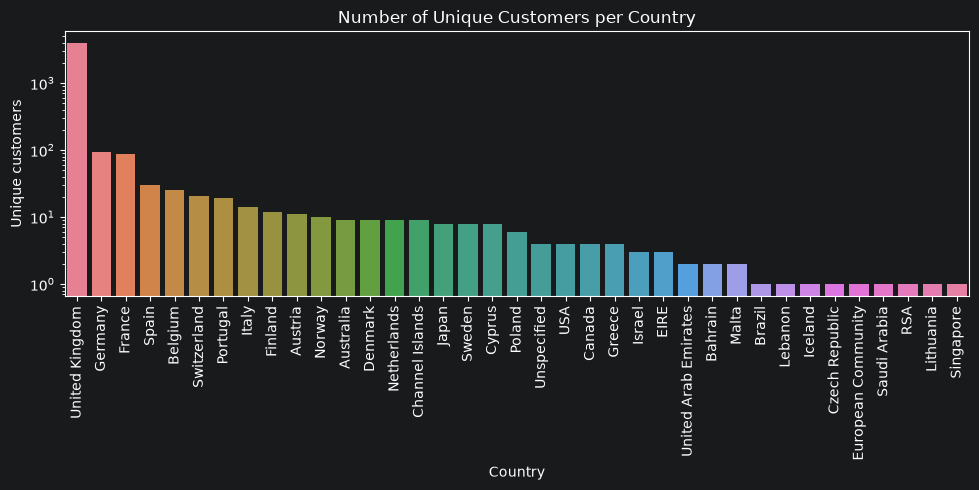

In [116]:
cust_per_country = (
    df.groupby("Country")["CustomerID"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=cust_per_country.index, y=cust_per_country.values,
            hue=cust_per_country.index, legend=False)
plt.title("Number of Unique Customers per Country")
plt.ylabel("Unique customers")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log")
plt.show()

### Sales per countery

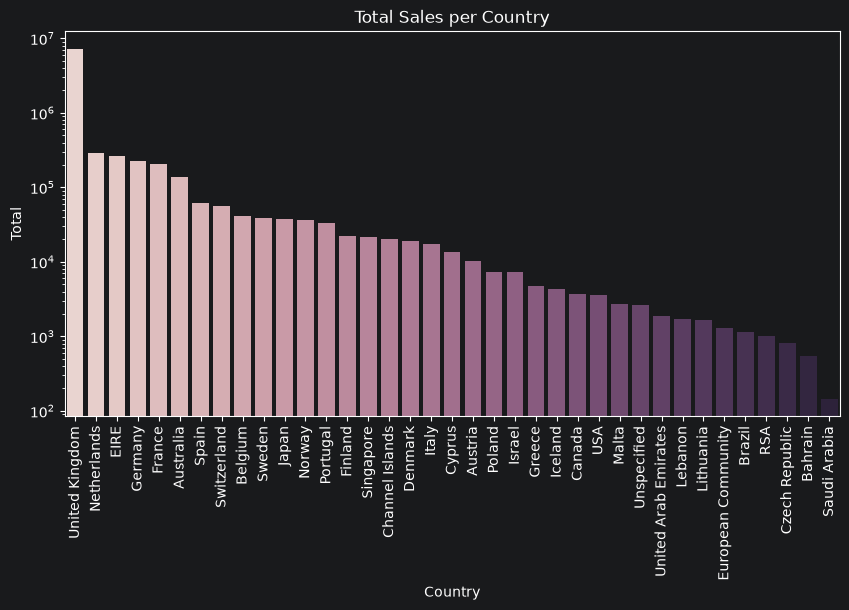

In [117]:
df["Total"] = df["Quantity"] * df["UnitPrice"]

data = (
    df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="Country", y="Total", hue=data.index, legend=False)
plt.xticks(rotation=90)
plt.title("Total Sales per Country")
plt.yscale("log")
plt.show()

# RFM

In [118]:
CRFM = pd.DataFrame(df["CustomerID"].unique(), columns=["CustomerID"])

### Monetary

In [119]:
CRFM = df.groupby("CustomerID")["Total"].sum().rename("Monetary").reset_index()
CRFM

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4333,18280,180.60
4334,18281,80.82
4335,18282,178.05
4336,18283,2045.53


### Recency

In [120]:
last_sale = df.groupby("CustomerID")["InvoiceDate"].max()
CRFM["LastSale"] = CRFM["CustomerID"].map(last_sale)

snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
CRFM["Recency"] = (snapshot - CRFM["LastSale"]).dt.days
CRFM.drop(columns=["LastSale"], inplace=True)
CRFM

,CustomerID,Monetary,Recency
0,12346,77183.60,326
1,12347,4310.00,3
2,12348,1797.24,76
3,12349,1757.55,19
4,12350,334.40,311
...,...,...,...
4333,18280,180.60,278
4334,18281,80.82,181
4335,18282,178.05,8
4336,18283,2045.53,4


### Frequency

In [121]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()
CRFM["Frequency"] = CRFM["CustomerID"].map(frequency)
CRFM

,CustomerID,Monetary,Recency,Frequency
0,12346,77183.60,326,1
1,12347,4310.00,3,7
2,12348,1797.24,76,4
3,12349,1757.55,19,1
4,12350,334.40,311,1
...,...,...,...,...
4333,18280,180.60,278,1
4334,18281,80.82,181,1
4335,18282,178.05,8,2
4336,18283,2045.53,4,16


# RFM Visualization

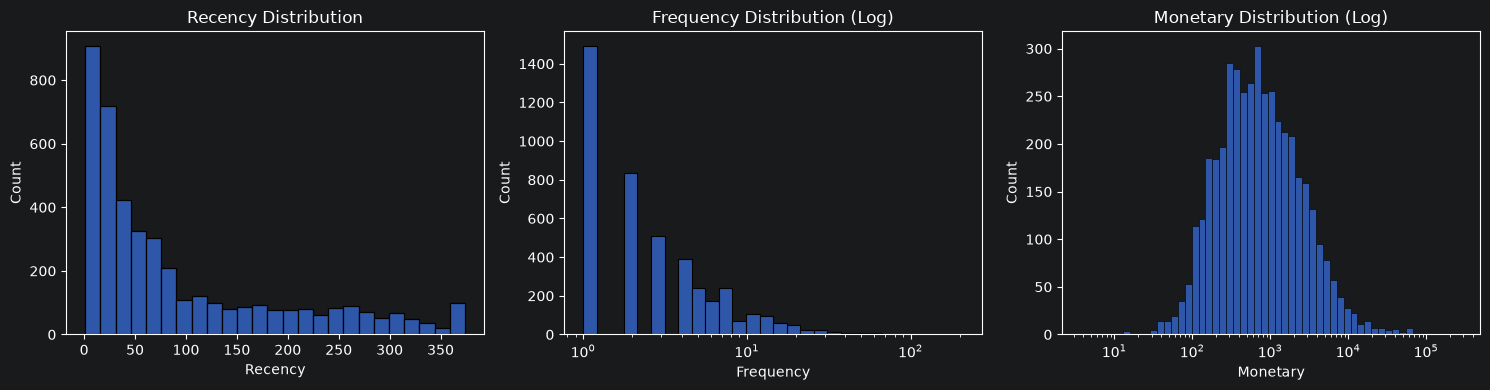

In [122]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

sns.histplot(CRFM["Recency"], ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(CRFM["Frequency"], ax=axes[1], log_scale=True)
axes[1].set_title("Frequency Distribution (Log)")

sns.histplot(CRFM["Monetary"], ax=axes[2], log_scale=True)
axes[2].set_title("Monetary Distribution (Log)")

plt.tight_layout()
plt.show()

# Normalisation

In [123]:
RFM = (CRFM[["Recency", "Frequency", "Monetary"]] - CRFM[["Recency", "Frequency", "Monetary"]].min()) / (CRFM[["Recency", "Frequency", "Monetary"]].max() - CRFM[["Recency", "Frequency", "Monetary"]].min())
CRFM

,CustomerID,Monetary,Recency,Frequency
0,12346,77183.60,326,1
1,12347,4310.00,3,7
2,12348,1797.24,76,4
3,12349,1757.55,19,1
4,12350,334.40,311,1
...,...,...,...,...
4333,18280,180.60,278,1
4334,18281,80.82,181,1
4335,18282,178.05,8,2
4336,18283,2045.53,4,16


# K-means

## Elbow method

In [124]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import numpy as np

In [125]:
inertias = []
mapping = {}
K = range(1, 20)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(RFM)

    inertias.append(kmeanModel.inertia_)

    mapping[k] = inertias[-1]

Inertia values:
1 : 322.2016796174173
2 : 74.17245606261851
3 : 40.888664982568315
4 : 27.231980492775776
5 : 22.69877710396473
6 : 16.135404663007115
7 : 12.822296369084729
8 : 10.89959976219697
9 : 9.533906412425445
10 : 8.22358380437902
11 : 7.261350673535966
12 : 6.37683570606396
13 : 5.391436817142388
14 : 5.121833696546139
15 : 4.521237354738821
16 : 4.0137003238265105
17 : 3.5892986044391684
18 : 3.3008333462622828
19 : 3.1573119090701995


/tmp/ipykernel_64577/178348552.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K, inertias, "bx-",color="red")


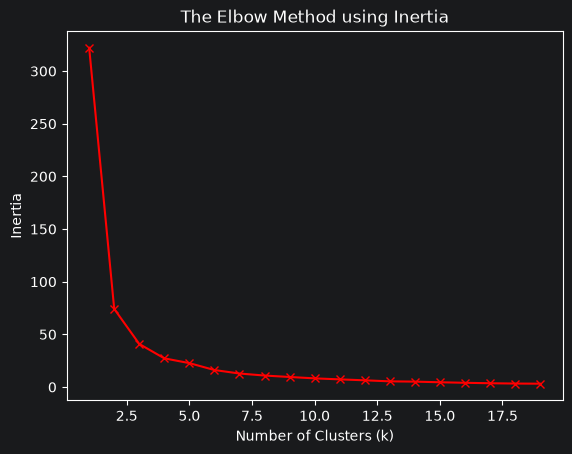

In [126]:
print("Inertia values:")
for key, val in mapping.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, "bx-",color="red")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

### Elbow curve analysis
From the above graph, we can deduce that the best k-means sits between 3 <= k >= 7

## Silouhette score

In [152]:
valid_K = range(2,11)
scors = {}
for k in valid_K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    predicted_labels = kmeanModel.fit_predict(RFM)
    scors[k] = silhouette_score(RFM, predicted_labels)

In [153]:
for s in scors:
    print(f"Silhouette score for {s} clusters: {scors[s]}")

Silhouette score for 2 clusters: 0.722462467509303
Silhouette score for 3 clusters: 0.6453793232120032
Silhouette score for 4 clusters: 0.5613883945979155
Silhouette score for 5 clusters: 0.5530516658752731
Silhouette score for 6 clusters: 0.5608771543557903
Silhouette score for 7 clusters: 0.5391836632675062
Silhouette score for 8 clusters: 0.47051915693962615
Silhouette score for 9 clusters: 0.4931212297249
Silhouette score for 10 clusters: 0.49431638162747193


### Silouhette score analysis
We guessed before that 3 <= k >= 7, but for testing pourpuses, we calculeted the score of (2,11).
The results was close enough to our previous guess, the best score belonged to k = 2 with a score of 0.722

### Difference between the best k (2) and the demanded one (3)
Although 2 was shown to be the best k, 3 would allow an Ecomerce buiseness which our data is from to handdle a more diverse pool of clients, as categorizing people to 3 groups with a right middle left mentality gives more options to make strategies to capture them than a plain either 1 or 2

In [135]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
rfm = pca.fit_transform(RFM)
KModel = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = KModel.fit_predict(rfm)
CRFM["Cluster"] = labels
rfm

array([[ 0.62054032,  0.18025166],
       [-0.24185953,  0.00606944],
       [-0.04563813, -0.00332072],
       ...,
       [-0.22735918, -0.02136043],
       [-0.24064869,  0.03468061],
       [-0.13386561, -0.01033091]], shape=(4338, 2))

# Cluster visualization

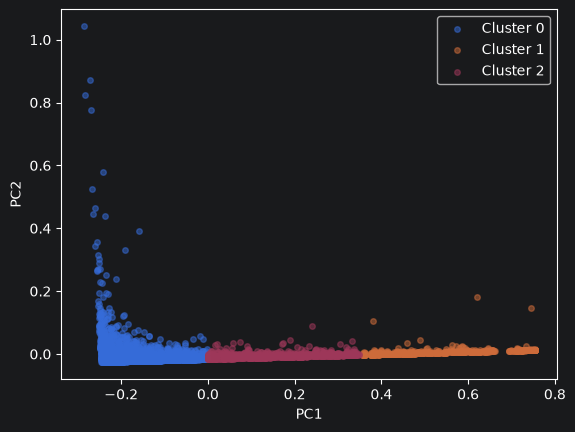

In [130]:
u_labels = np.unique(labels)
for i in u_labels:
    plt.scatter(rfm[labels == i , 0] , rfm[labels == i , 1] , label = f"Cluster {i}", alpha=0.5, s=16)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## RFM Cluster Profiling

In [207]:
stats = CRFM.groupby("Cluster").agg(
    number_of_customers=("Cluster", "size"),
    avg_recency=("Recency", "mean"),
    median_recency=("Recency", "median"),
    avg_frequency=("Frequency", "mean"),
    median_frequency=("Frequency", "median"),
    avg_monetary=("Monetary", "mean"),
    median_monetary=("Monetary", "median"),
    total_revenue=("Monetary", "sum"),
).round(2)
stats.columns = pd.MultiIndex.from_tuples([
    ("Customers", "count"),
    ("Recency", "mean"), ("Recency", "median"),
    ("Frequency", "mean"), ("Frequency", "median"),
    ("Monetary", "mean"), ("Monetary", "median"), ("Monetary", "sum"),
])
stats

Customers Recency        Frequency        Monetary                    
            count    mean median      mean median     mean  median         sum
Cluster                                                                       
0            2898   32.52   26.0      5.48    3.0  2712.60  981.68  7861101.14
1             626  294.94  288.0      1.35    1.0   605.72  289.30   379178.32
2             814  153.32  152.0      2.22    2.0   794.75  463.02   646925.53

In [208]:
stats.insert(0, "cluster_name", ["Loyal", "Lost", "Casual"])

In [211]:
stats = stats.reindex([0,2,1])
stats

cluster_name Customers Recency        Frequency        Monetary  \
                         count    mean median      mean median     mean   
Cluster                                                                   
0              Loyal      2898   32.52   26.0      5.48    3.0  2712.60   
2             Casual       814  153.32  152.0      2.22    2.0   794.75   
1               Lost       626  294.94  288.0      1.35    1.0   605.72   

                             
         median         sum  
Cluster                      
0        981.68  7861101.14  
2        463.02   646925.53  
1        289.30   379178.32

## Clusters observation
From the statistics above,

In [170]:

# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.cluster import DBSCAN
# from sklearn.neighbors import NearestNeighbors

# min_samples = 6
# dist, _ = NearestNeighbors(n_neighbors=min_samples).fit(RFM).kneighbors(RFM)
# plt.plot(np.sort(dist[:, -1]))
# plt.xlabel("Points (sorted)"); plt.ylabel(f"Distance to {min_samples}th neighbor")
# plt.show()

# db = DBSCAN(eps=0.05, min_samples=min_samples).fit(RFM)
# labels = db.labels_
# n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
# print("Clusters:", n_clusters, "| Noise points:", (labels == -1).sum())
#
# coords = PCA(n_components=2).fit_transform(RFM)
# for lab in sorted(set(labels)):
#     m = labels == lab
#     if lab == -1:
#         plt.scatter(coords[m, 0], coords[m, 1], c="k", marker="x", s=15, label="Noise")
#     else:
#         plt.scatter(coords[m, 0], coords[m, 1], s=15, alpha=0.6, label=f"Cluster {lab}")
# plt.title(f"DBSCAN: {n_clusters} clusters")
# plt.legend(); plt.show()
#
# mask = labels != -1
# if n_clusters >= 2:
#     print("Silhouette (no noise):", silhouette_score(RFM[mask], labels[mask]))